# $\nu_e$ CC Inclusive Selection + Syst. Analysis

In [1]:
# =============================================================================
# CELL 0 — imports & paths
# =============================================================================
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./plots_syst_v1"
DF_OUT_DIR   = "./nuecc_dfs"
# DF_FILE      = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_2605.df"
DF_FILE = "/home/castalyf/cafpyana_out/mc1e20_nueCC_test_small.df"
TARGET_POT   = 6.6e20
TITLE        = r"SBND $\nu_e$ CC Inclusive"

os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

import nue_helpers   as nh
import nue_selection as ns
%load_ext autoreload
%autoreload 2


In [2]:
with pd.HDFStore(DF_FILE, mode="r") as store:
    keys = store.keys()
    print(f"Keys: {keys}")
    has_split = "/split" in keys

if has_split:
    with pd.HDFStore(DF_FILE, mode="r") as store:
        n_splits = int(store["split"]["n_split"].iloc[0])
    print(f"Split format: {n_splits} splits")
    evt_frames   = [pd.read_hdf(DF_FILE, key=f"evt_{k}")        for k in range(n_splits)]
    stats_frames = [pd.read_hdf(DF_FILE, key=f"stats_{k}")      for k in range(n_splits)]
    hist_frames  = [pd.read_hdf(DF_FILE, key=f"histpotdf_{k}")  for k in range(n_splits)]
else:
    print("Merged format: single tables")
    with pd.HDFStore(DF_FILE, mode="r") as store:
        evt_keys  = sorted([k for k in keys if k.lstrip("/").startswith("evt")])
        stat_keys = sorted([k for k in keys if k.lstrip("/").startswith("stats")])
        hist_keys = sorted([k for k in keys if "histpotdf" in k])
    evt_frames   = [pd.read_hdf(DF_FILE, key=k) for k in evt_keys]
    stats_frames = [pd.read_hdf(DF_FILE, key=k) for k in stat_keys]
    hist_frames  = [pd.read_hdf(DF_FILE, key=k) for k in hist_keys]

evtdf     = pd.concat(evt_frames,   axis=0)
statsdf   = pd.concat(stats_frames, axis=0)
histpotdf = pd.concat(hist_frames,  axis=0) if hist_frames else pd.DataFrame()

print(f"\nevtdf   shape : {evtdf.shape}")
print(f"statsdf shape : {statsdf.shape}")

Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/pot_0', '/split', '/stats_0']
Split format: 1 splits

evtdf   shape : (110842, 393)
statsdf shape : (5, 14)


In [3]:
# histpotdf already loaded in Cell 1 — use directly
print("histpotdf columns:", histpotdf.columns.tolist())
print(histpotdf.head())

pot_col   = "TotalPOT" if "TotalPOT" in histpotdf.columns \
            else histpotdf.select_dtypes("number").columns[0]
total_pot = float(histpotdf[pot_col].sum())
pot_scale = TARGET_POT / total_pot if total_pot > 0 else float("nan")

print(f"Total POT    : {total_pot:.3e}")
print(f"Target POT   : {TARGET_POT:.3e}")
print(f"Scale factor : {pot_scale:.4f}")

n_true_signal        = int(statsdf["n_true_signal"].sum())
n_inter_after_fm     = int(statsdf["n_after_fm"].sum())
n_inter_after_presel = int(statsdf["n_after_presel"].sum())
n_sig_after_fm       = int(statsdf["n_sig_after_fm"].sum())
n_sig_after_presel   = int(statsdf["n_sig_after_presel"].sum())

print(f"True signal (pre-cut)   : {n_true_signal:,}  <- denominator")
print(f"Signal after FM         : {n_sig_after_fm:,}  ({n_sig_after_fm/n_true_signal*100:.1f}%)")
print(f"Signal after FM+FV      : {n_sig_after_presel:,}  ({n_sig_after_presel/n_true_signal*100:.1f}%)")

histpotdf columns: ['TotalPOT']
                    TotalPOT
__ntuple entry              
0        0      7.545876e+17
3        0      7.523471e+17
2        0      7.556371e+17
1        0      7.517843e+17
4        0      7.546533e+17
Total POT    : 3.769e+18
Target POT   : 6.600e+20
Scale factor : 175.1123
True signal (pre-cut)   : 113  <- denominator
Signal after FM         : 99  (87.6%)
Signal after FM+FV      : 99  (87.6%)


In [4]:
n_true_signal      = int(statsdf["n_true_signal"].sum())
n_inter_after_fm   = int(statsdf["n_after_fm"].sum())       # all interactions after FM
n_inter_after_presel = int(statsdf["n_after_presel"].sum()) # all interactions after FM+FV
n_sig_after_fm     = int(statsdf["n_sig_after_fm"].sum())   # signal after FM
n_sig_after_presel = int(statsdf["n_sig_after_presel"].sum()) # signal after FM+FV

print(f"True signal (pre-cut)   : {n_true_signal:,}  <- denominator")
print(f"Signal after FM         : {n_sig_after_fm:,}  ({n_sig_after_fm/n_true_signal*100:.1f}%)")
print(f"Signal after FM+FV      : {n_sig_after_presel:,}  ({n_sig_after_presel/n_true_signal*100:.1f}%)")
# print(f"Signal visible in evtdf : {len(sig_inter_idx):,}  (should match n_sig_after_presel)")



True signal (pre-cut)   : 113  <- denominator
Signal after FM         : 99  (87.6%)
Signal after FM+FV      : 99  (87.6%)


In [5]:
# =============================================================================
# CELL 3 — alignment helpers (same as before)
# =============================================================================
il               = nh.inter_levels(evtdf)
presel_inter     = evtdf.groupby(level=il).size().index
truth_cat_presel = evtdf.groupby(level=il).first()  # interaction-level view

# NOTE: with the new df, truth_info_0 is not written separately.
# truth categories come from classify_truth or from statsdf aggregate counts.
# For per-interaction truth_cat, use classify_truth:
truth_cat_presel = ns.classify_truth(evtdf, verbose=True)
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)

sig_inter_idx   = truth_cat_presel[truth_cat_presel == 0].index
sig_mask_presel = presel_inter.isin(sig_inter_idx)

print(f"\nSignal visible in evtdf : {len(sig_inter_idx):,}")
print(f"True denominator        : {n_true_signal:,}")

classify_truth: reading true-interaction flags …
  is_nu        :   22,170
  is_cc        :   17,185
  is_fv (true) :   19,019
  true_elec    :      172
  true_muon    :   16,491
  has_pi0      :    3,083

=== Truth category summary ===
  cat  0  nueCC FV (signal)     :       99
  cat  1  nueCC out FV          :        5
  cat  2  numuCC + π⁰           :    1,784
  cat  3  NC π⁰                 :    1,087
  cat  4  other numuCC          :   14,153
  cat  5  other NC              :    3,898
  cat  6  cosmic                :    1,005
  cat  7  other neutrino        :    1,144
  total                     :   23,175
=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 271
Raw min  : 10.7048
Raw max  : 3501.4021
Raw mean : 620.8404
Raw median: 397.6704
After *1000 (GeV→MeV)  → min/max: 10704.8 – 3501402.1 MeV
After *1     (already MeV) → min/max: 10.7 – 3501.4 MeV

Signal visible in evtdf : 99
True denominator        : 113


Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 271
Raw min  : 10.7048
Raw max  : 3501.4021
Raw mean : 620.8404
Raw median: 397.6704
After *1000 (GeV→MeV)  → min/max: 10704.8 – 3501402.1 MeV
After *1     (already MeV) → min/max: 10.7 – 3501.4 MeV

Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)               113     0.00%        100.0%
  Flash match                   40,524     0.24%         87.6%
  In FV                         23,175     0.43%         87.6%
  Final state topology             630    16.67%         83.2%


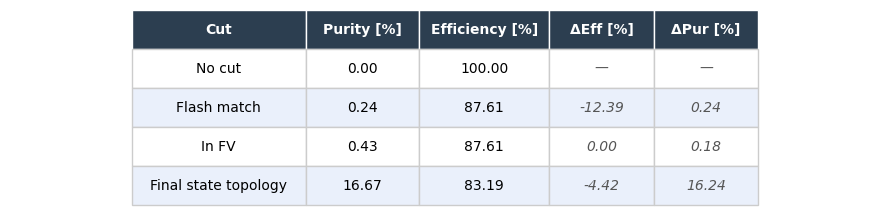

In [6]:
# =============================================================================
# CELL 4 — cut flow + table + save sel_topo  (earliest possible save point)
# =============================================================================
import gc

cut_flow          = ns.build_cut_flow(evtdf)
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)

def _purity(stage_idx):
    n_no7 = int((truth_cat_presel.reindex(stage_idx).fillna(7) != 7).sum())
    if n_no7 == 0:
        return float("nan")
    return int((truth_cat_presel.reindex(stage_idx) == 0).sum()) / n_no7

se_idx   = cut_flow["single_electron"]["inter_index"]
n_sig_se = int((truth_cat_presel.reindex(se_idx) == 0).sum())

eff_fm = n_sig_after_fm     / n_true_signal      if n_true_signal      > 0 else float("nan")
eff_fv = n_sig_after_presel / n_true_signal      if n_true_signal      > 0 else float("nan")
eff_se = n_sig_se           / n_true_signal      if n_true_signal      > 0 else float("nan")
pur_fm = n_sig_after_fm     / n_inter_after_fm   if n_inter_after_fm   > 0 else float("nan")
pur_fv = n_sig_after_presel / n_inter_after_presel if n_inter_after_presel > 0 else float("nan")
pur_se = _purity(se_idx)

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_true_signal:>9,}  {'0.00%':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_after_fm:>9,}  {pur_fm*100:>7.2f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_after_presel:>9,}  {pur_fv*100:>7.2f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {len(se_idx):>9,}  {pur_se*100:>7.2f}%  {eff_se*100:>11.1f}%")

CUT_DISPLAY = ["No cut", "Flash match", "In FV", "Final state topology"]
purs_table  = [0.0, pur_fm, pur_fv, pur_se]
effs_table  = [1.0, eff_fm, eff_fv, eff_se]
fig_tbl, ax_tbl = plt.subplots(figsize=(9, 2.6))
nh.create_purity_efficiency_table(purs_table, effs_table, CUT_DISPLAY, ax_tbl)
fig_tbl.tight_layout()
plt.show()
nh.save_plot("pur_eff_table", fig=fig_tbl, folder_name=PLOT_DIR)

In [7]:
# ── Save sel_topo — all evtdf-dependent calls happen exactly once here ────────
os.makedirs(DF_OUT_DIR, exist_ok=True)
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo_v2.df")
_stage_idx_topo = {
    "precut"          : presel_inter,
    "valid_flashmatch": presel_inter,
    "fiducial"        : presel_inter,
    "single_electron" : se_idx,
}
sel_topo = nh.build_and_save_selection(
    path             = SEL_TOPO_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_cos         = ns.leading_electron_costheta(evtdf),
    reco_p           = ns.leading_electron_p(evtdf),
    true_ke          = true_ke_all,           # already computed above
    true_cos         = true_costheta_all,     # already computed above
    true_p           = ns.true_leading_electron_p(evtdf),
    stage_idx_dict   = _stage_idx_topo,
    cut_names        = list(_stage_idx_topo.keys()),
    pot_scale        = pot_scale,
)
print(f"sel_topo saved → {SEL_TOPO_FILE}  shape: {sel_topo.shape}")
print(f"  cols: {list(sel_topo.columns)}")
# evtdf still alive — threshold scans need it

Saved selection df → ./nuecc_dfs/selected_nuecc_topo_v2.df
  shape=(23175, 13)  size=0.1 MB
sel_topo saved → ./nuecc_dfs/selected_nuecc_topo_v2.df  shape: (23175, 13)
  cols: ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'pot_scale']


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


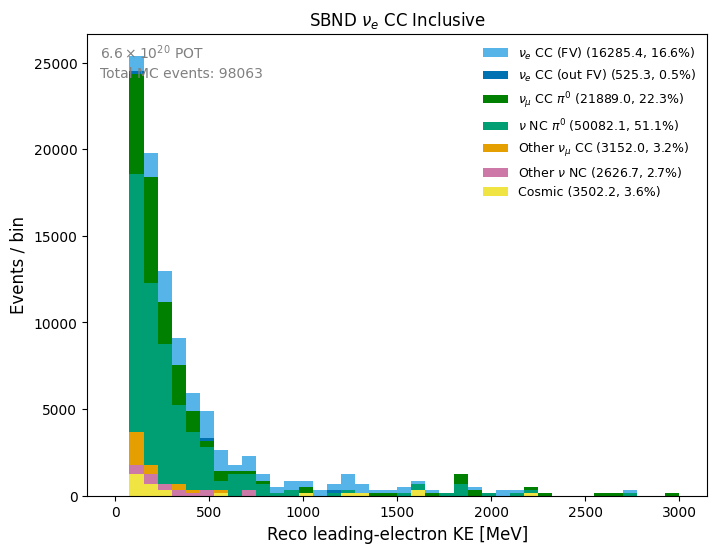

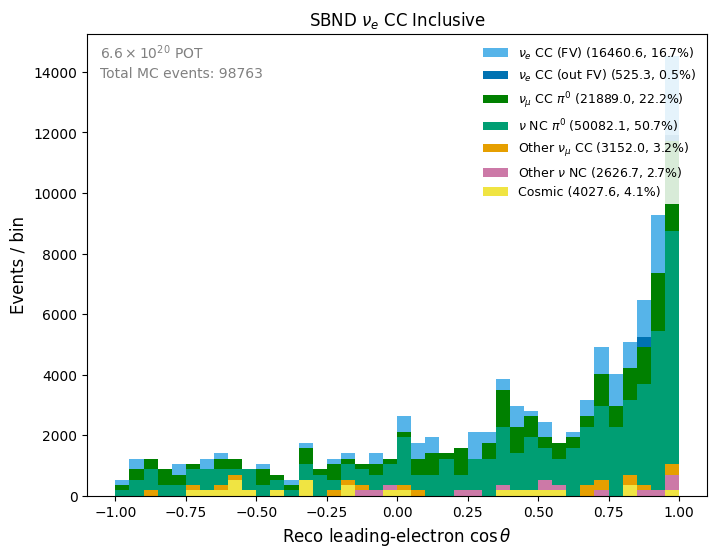

In [8]:
# =============================================================================
# CELL 7 — topology stacked histograms (from sel_topo)

DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]
def _topo_cat(col, cat):
    mask = sel_topo["sel_single_electron"] & (sel_topo["truth_cat"] == cat)
    return sel_topo.loc[mask, col].dropna().values

_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]
bins_ke  = np.concatenate([np.linspace(0, 3000, 41)])
bins_cos = np.linspace(-1, 1, 41)

fig_ke, ax_ke = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=bins_ke, weights=pot_scale,
    xlabel="Reco leading-electron KE [MeV]", title=fr"{TITLE}",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_ke, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke", fig=fig_ke, folder_name=PLOT_DIR)

fig_cos, ax_cos = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=bins_cos, weights=pot_scale,
    xlabel=r"Reco leading-electron $\cos\theta$", title=fr"{TITLE}",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_cos, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta", fig=fig_cos, folder_name=PLOT_DIR)

In [9]:
# =============================================================================
# CELL 10 — shower qual cuts + save sel_qual + del evtdf
# =============================================================================
cut_flow_sq = ns.shower_qual_cuts(evtdf)

# ── Build stage index dict ────────────────────────────────────────────────────
_stage_idx_qual = {
    "precut"          : presel_inter,
    "valid_flashmatch": presel_inter,
    "fiducial"        : presel_inter,
}
for _name in ns.CUT_NAMES_MORE:
    if _name not in _stage_idx_qual:
        _stage_idx_qual[_name] = cut_flow_sq[_name]["inter_index"]

# ── Save sel_qual — reuse sel_topo columns, no re-extraction from evtdf ───────
SEL_QUAL_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_qual_v2.df")
sel_qual = nh.build_and_save_selection(
    path             = SEL_QUAL_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = sel_topo["reco_ke"],        # ← sel_topo, not evtdf
    reco_cos         = sel_topo["reco_costheta"],  # ← sel_topo, not evtdf
    reco_p           = sel_topo["reco_p"],         # ← sel_topo, not evtdf
    true_ke          = sel_topo["true_ke"],        # ← sel_topo, not evtdf
    true_cos         = sel_topo["true_costheta"],  # ← sel_topo, not evtdf
    true_p           = sel_topo["true_p"],         # ← sel_topo, not evtdf
    stage_idx_dict   = _stage_idx_qual,
    cut_names        = ns.CUT_NAMES_MORE,
    pot_scale        = pot_scale,
)
del evtdf
gc.collect()
print(f"evtdf freed.  sel_qual saved → {SEL_QUAL_FILE}  shape: {sel_qual.shape}")

# ── Purity / efficiency print table ──────────────────────────────────────────
def _row_stats(stage_idx):
    n_no7 = int((truth_cat_presel.reindex(stage_idx).fillna(7) != 7).sum())
    n_sig  = int((truth_cat_presel.reindex(stage_idx) == 0).sum())
    pur    = n_sig / n_no7         if n_no7         > 0 else float("nan")
    eff    = n_sig / n_true_signal if n_true_signal  > 0 else float("nan")
    return len(stage_idx), pur, eff

sq_names  = ns.CUT_NAMES_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_labels = ns.CUT_LABELS_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_rows   = {name: _row_stats(_stage_idx_qual[name]) for name in sq_names}

W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_true_signal:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_after_fm:>9,}  {'—':>8}  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_after_presel:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {len(se_idx):>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")
for name, label in zip(sq_names, sq_labels):
    n_i, pur, eff = sq_rows[name]
    print(f"  {label:<{W-2}} {n_i:>9,}  {pur*100:>7.1f}%  {eff*100:>11.1f}%")

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Applying extra shower-quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]

Saved selection df → ./nuecc_dfs/selected_nuecc_qual_v2.df
  shape=(23175, 16)  size=0.1 MB
evtdf freed.  sel_qual saved → ./nuecc_dfs/selected_nuecc_qual_v2.df  shape: (23175, 16)

Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)               113         —        100.0%
  Flash match                   40,524         —         87.6%
  In FV                         23,175      0.4%         87.6%
  Final state topology             630     16.7%         83.2%
  Electron Primary score           329     25.3%         64.6%
  Electron PID score               116     61.2%         55.8%
  Conversion gap                    99     69.0%         53.1%


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


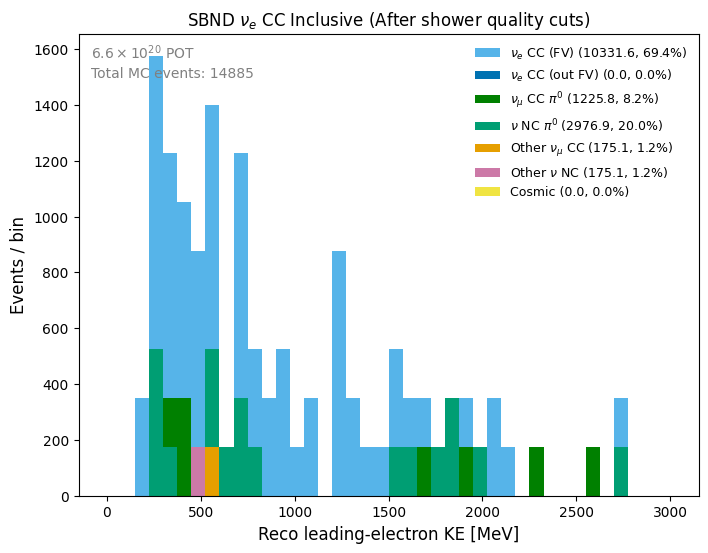

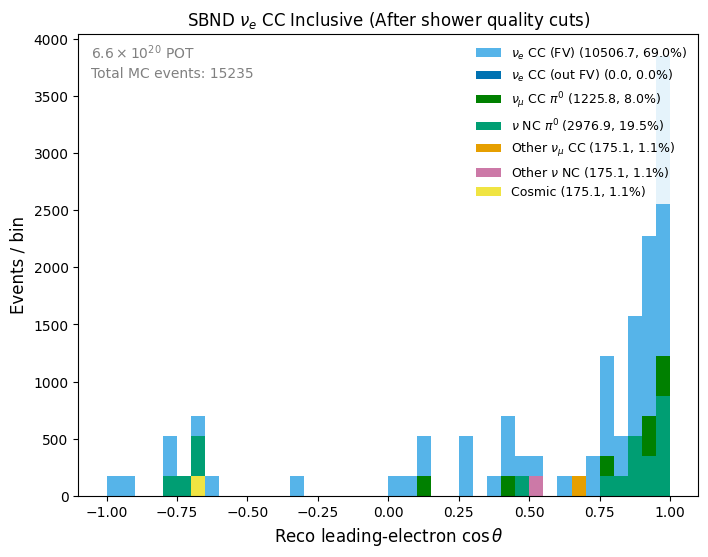

In [10]:
# ── Final stacked histograms ──────────────────────────────────────────────────
final_col = f"sel_{ns.CUT_NAMES_MORE[-1]}"

def _qual_cat(col, cat):
    mask = sel_qual[final_col] & (sel_qual["truth_cat"] == cat)
    mask = mask & sel_qual["reco_ke"].notna() & sel_qual["reco_costheta"].notna()
    return sel_qual.loc[mask, col].values

fig_ke2, ax_ke2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.concatenate([np.linspace(0, 3000, 41)]),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_ke2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke_final", fig=fig_ke2, folder_name=PLOT_DIR)

fig_cos2, ax_cos2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT", ax=ax_cos2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta_final", fig=fig_cos2, folder_name=PLOT_DIR)

In [11]:
# =============================================================================
# CELL S0 — load mcnu weights (handles both split and merged format)
# =============================================================================
import gc
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
 
sys.path.insert(0, "/home/castalyf/cafpyana")
sys.path.insert(0, "/home/castalyf/cafpyana/pyanalib")
from analysis_village.unfolding.covariance import (
    get_covariance_matrix_self,
    get_covariance_matrix,
)
from analysis_village.unfolding.utils import plot_univ_hists, plot_heatmap
 
# WEIGHTS_FILE = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_weights_2605.df"
WEIGHTS_FILE = "/home/castalyf/cafpyana_out/nueCC_weights_test.df"

def _load_all_splits(hdf_file, key_prefix):
    """Load all splits of a given key from either merged or split-format file."""
    with pd.HDFStore(hdf_file, mode="r") as store:
        keys     = store.keys()
        has_split = "/split" in keys
        if has_split:
            n = int(store["split"]["n_split"].iloc[0])
            return pd.concat([store[f"{key_prefix}_{k}"] for k in range(n)], axis=0)
        else:
            matching = sorted([k for k in keys if k.lstrip("/").startswith(key_prefix.lstrip("/"))])
            if not matching:
                return pd.DataFrame()
            return pd.concat([store[k] for k in matching], axis=0)
 
mcnu_df = _load_all_splits(WEIGHTS_FILE, "mcnu")
print(f"mcnu_df shape  : {mcnu_df.shape}")
print(f"mcnu_df index  : {mcnu_df.index.names}")
print(f"Sample columns : {list(mcnu_df.columns[:8])}")
 
# Detect universe columns
bnb_cols = [c for c in mcnu_df.columns
            if isinstance(c, tuple)
            and any(kw in str(p).lower() for p in c
                    for kw in ["bnb", "flux", "beam"])
            and any("univ" in str(p).lower() for p in c)]

genie_cols = [c for c in mcnu_df.columns
              if isinstance(c, tuple)
              and any(kw in str(p).lower() for p in c
                      for kw in ["genie", "xsr", "knob"])
              and any("univ" in str(p).lower() for p in c)]
print(f"BNB universe columns  : {len(bnb_cols)}")
print(f"GENIE universe columns: {len(genie_cols)}")
 
# =============================================================================
# print all available weight columns
# =============================================================================
print(f"\n{'='*60}")
print(f"mcnu_df shape: {mcnu_df.shape}")
print(f"{'='*60}")

# Group columns by systematic source
col_groups = {}
for c in mcnu_df.columns:
    if not isinstance(c, tuple):
        continue
    # Use second-level as group name (e.g. 'bnb', 'genie', 'E', 'baseline'...)
    group = str(c[1]) if len(c) > 1 else str(c[0])
    col_groups.setdefault(group, []).append(c)

print(f"\n{'Group':<30} {'N columns':>10}  {'Sample column'}")
print("-" * 70)
for grp, cols in sorted(col_groups.items()):
    is_univ = any("univ" in str(p).lower() for p in cols[0])
    tag     = " ← UNIVERSE WEIGHTS" if is_univ else ""
    print(f"  {grp:<28} {len(cols):>10}  {cols[0]}{tag}")

print(f"\nTotal columns: {len(mcnu_df.columns)}")
print(f"BNB universe columns  : {len(bnb_cols)}")
print(f"GENIE universe columns: {len(genie_cols)}")

mcnu_df shape  : (17536, 304)
mcnu_df index  : ['__ntuple', 'entry', 'rec.mc.nu..index']
Sample columns : [('E', '', ''), ('baseline', '', ''), ('time', '', ''), ('bjorkenX', '', ''), ('inelasticityY', '', ''), ('Q2', '', ''), ('w', '', ''), ('momentum', 'x', '')]
BNB universe columns  : 100
GENIE universe columns: 100

mcnu_df shape: (17536, 304)

Group                           N columns  Sample column
----------------------------------------------------------------------
                                       30  ('E', '', '')
  contained                             4  ('mu', 'contained', '')
  crosses_tpc                           4  ('mu', 'crosses_tpc', '')
  dir                                   6  ('mu', 'dir', 'x')
  end                                  12  ('mu', 'end', 'x')
  genE                                  4  ('mu', 'genE', '')
  genp                                 12  ('mu', 'genp', 'x')
  interaction_id                        4  ('mu', 'interaction_id', '')
  lengt

In [12]:
# =============================================================================
# CELL S0c — reload evtdf if deleted earlier to save memory
# =============================================================================
import gc
try:
    _ = evtdf.shape   # check if still in memory
    print(f"evtdf already loaded: {evtdf.shape}")
except NameError:
    print("evtdf not in memory — reloading from file ...")
    with pd.HDFStore(DF_FILE, mode="r") as store:
        keys      = store.keys()
        has_split = "/split" in keys
    if has_split:
        n = int(pd.read_hdf(DF_FILE, key="split")["n_split"].iloc[0])
        evtdf = pd.concat([pd.read_hdf(DF_FILE, key=f"evt_{k}")
                           for k in range(n)], axis=0)
    else:
        evt_keys = sorted([k for k in keys if k.lstrip("/").startswith("evt")])
        evtdf = pd.concat([pd.read_hdf(DF_FILE, key=k)
                           for k in evt_keys], axis=0)
    print(f"evtdf reloaded: {evtdf.shape}")
    gc.collect()

evtdf not in memory — reloading from file ...
evtdf reloaded: (110842, 393)


In [13]:
# =============================================================================
# CELL S1 — align mcnu weights to sel_topo interactions
# Merge via mct_index (dlp_true → rec.mc.nu..index)
# =============================================================================
# mct_index column in evtdf (interaction level)
il       = nh.inter_levels(evtdf)
inter_df = evtdf.groupby(level=il).first()
 
mct_col  = [c for c in inter_df.columns
            if "mct_index" in str(c) and "dlp_true" in str(c)][0]
print(f"mct_index column: {mct_col}")
 
# Build a lookup: interaction index → mcnu weight row
# mcnu_df is indexed by (__ntuple, entry, rec.mc.nu..index)
# inter_df has (__ntuple, entry, rec.dlp..index) with mct_col values
wgt_cols_to_keep = bnb_cols + genie_cols
if not wgt_cols_to_keep:
    print("WARNING: no universe weight columns found — MCstat only")
 
# Merge interaction-level mct_index to mcnu weights
inter_reset = inter_df[[mct_col]].reset_index()
mcnu_reset  = mcnu_df[wgt_cols_to_keep].reset_index() if wgt_cols_to_keep else pd.DataFrame()
 
if not mcnu_reset.empty:
    from pyanalib.pandas_helpers import multicol_merge
    wgt_aligned = multicol_merge(
        lhs      = inter_reset,
        rhs      = mcnu_reset,
        left_on  = [inter_reset.columns[0], inter_reset.columns[1], mct_col],
        right_on = [mcnu_reset.columns[0],  mcnu_reset.columns[1],
                    mcnu_df.index.names[-1]],
        how      = "left",
    ).set_index(inter_df.index.names)
    print(f"wgt_aligned shape: {wgt_aligned.shape}")
else:
    wgt_aligned = inter_df[[mct_col]].copy()
    print("No universe weights — wgt_aligned is placeholder")


bnb_cols_aligned = [c for c in wgt_aligned.columns
                    if isinstance(c, tuple)
                    and any(kw in str(p).lower() for p in c
                            for kw in ["bnb", "flux", "beam"])
                    and any("univ" in str(p).lower() for p in c)]

genie_cols_aligned = [c for c in wgt_aligned.columns
                      if isinstance(c, tuple)
                      and any(kw in str(p).lower() for p in c
                              for kw in ["genie", "xsr", "knob"])
                      and any("univ" in str(p).lower() for p in c)]

print(f"BNB cols in wgt_aligned  : {len(bnb_cols_aligned)}")
print(f"GENIE cols in wgt_aligned: {len(genie_cols_aligned)}")
print(f"wgt_aligned columns nlevels: {wgt_aligned.columns.nlevels}")

del inter_reset, mcnu_reset
gc.collect()

mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


/home/castalyf/cafpyana/pyanalib/pandas_helpers.py:85: PerformanceWarning: indexing past lexsort depth may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


wgt_aligned shape: (23175, 206)
BNB cols in wgt_aligned  : 100
GENIE cols in wgt_aligned: 100
wgt_aligned columns nlevels: 5


0

In [14]:
# =============================================================================
# CELL S2 — VariableConfig for nueCC (mirrors cohpi VariableConfig)
# =============================================================================
RECO_BINS = np.linspace(0, 2000, 11)   # 10 reco KE bins
TRUE_BINS = np.linspace(0, 2000, 11)   # 10 true KE bins
 
class NueCCVarConfig:
    def __init__(self):
        self.bins        = RECO_BINS
        self.bin_centers = 0.5 * (RECO_BINS[:-1] + RECO_BINS[1:])
        self.var_plot_name = "Reco leading-e KE [MeV]"
        self.var_labels    = [
            "Reco $e^-$ KE [MeV]",
            "Reco $e^-$ KE [MeV]",
            "True $e^-$ KE [MeV]",
        ]
 
varcfg = NueCCVarConfig()

In [15]:
# =============================================================================
# CELL S3 — build CV histograms from sel_topo
# signal = cat 0, background = cat 1-6 (exclude cat 7)
# =============================================================================
eps       = 1e-8
stage_col = "sel_single_electron"
sel_s     = sel_topo[sel_topo[stage_col]]
 
sig_mask  = (sel_s["truth_cat"] == 0)
bkg_mask  = (sel_s["truth_cat"].between(1, 6))
 
reco_ke   = sel_s["reco_ke"].clip(RECO_BINS[0], RECO_BINS[-1] - eps)
 
ms_cv, _ = np.histogram(reco_ke[sig_mask], bins=RECO_BINS,
                        weights=np.full(sig_mask.sum(), pot_scale))
bs_cv, _ = np.histogram(reco_ke[bkg_mask], bins=RECO_BINS,
                        weights=np.full(bkg_mask.sum(), pot_scale))
 
# True signal for response/efficiency
true_ke_sig = sel_s.loc[sig_mask, "true_ke"].dropna()
true_signal_cv, _ = np.histogram(
    true_ke_sig.clip(TRUE_BINS[0], TRUE_BINS[-1] - eps),
    bins=TRUE_BINS, weights=np.full(len(true_ke_sig), pot_scale)
)
 
# Response matrix
valid_both = sig_mask & sel_s["reco_ke"].notna() & sel_s["true_ke"].notna()
reco_vs_true, _, _ = np.histogram2d(
    sel_s.loc[valid_both, "true_ke"].clip(TRUE_BINS[0], TRUE_BINS[-1] - eps),
    reco_ke[valid_both],
    bins=[TRUE_BINS, RECO_BINS],
)
col_sums = reco_vs_true.sum(axis=1, keepdims=True).clip(1)
response = reco_vs_true / col_sums
 
print(f"CV signal hist  : {ms_cv}")
print(f"CV bkg hist     : {bs_cv}")
print(f"True signal hist: {true_signal_cv}")
print(f"Response shape  : {response.shape}")

CV signal hist  : [2101.34785147 3677.35874008 3677.35874008 1576.0108886   875.56160478
 1050.67392574 1576.0108886   525.33696287  350.22464191 1050.67392574]
CV bkg hist     : [37999.37364747 25041.06189672  8230.27908493  3327.13409817
  1050.67392574   700.44928382   525.33696287   700.44928382
   875.56160478  3852.47106103]
True signal hist: [ 875.56160478 4552.92034486 3327.13409817 1751.12320956 1050.67392574
  875.56160478 1225.78624669  875.56160478  875.56160478 1050.67392574]
Response shape  : (10, 10)


In [16]:
# =============================================================================
# CELL S4 — build universe histograms (one array per syst source)
# Shape: (n_universes, n_bins) for signal, same for background
# =============================================================================
def _build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
                      reco_ke_col, bins, pot_scale):
    sel_s    = sel_df[sel_df[stage_col]]
    sig_mask = (sel_s["truth_cat"] == 0).values
    bkg_mask = sel_s["truth_cat"].between(1, 6).values
    reco_ke  = sel_s[reco_ke_col].clip(bins[0], bins[-1] - 1e-8).values

    # ── Align index levels: wgt_aligned has 3 levels, sel_s may have more ──
    n_wgt_levels = wgt_aligned.index.nlevels   # typically 3
    if sel_s.index.nlevels > n_wgt_levels:
        # Drop extra levels (e.g. particle level) to get interaction-level index
        levels_to_drop = list(range(n_wgt_levels, sel_s.index.nlevels))
        sel_inter_idx = sel_s.index.droplevel(levels_to_drop)
    else:
        sel_inter_idx = sel_s.index

    wgts_sel = wgt_aligned[univ_cols].reindex(sel_inter_idx).values  # numpy array

    n_univ  = len(univ_cols)
    n_bins  = len(bins) - 1
    sig_univs = np.zeros((n_univ, n_bins))
    bkg_univs = np.zeros((n_univ, n_bins))

    for ui in tqdm(range(n_univ), desc="Universes", leave=False):
        w = np.where(np.isnan(wgts_sel[:, ui]), 1.0, wgts_sel[:, ui]) * pot_scale
        sig_univs[ui], _ = np.histogram(reco_ke[sig_mask], bins=bins, weights=w[sig_mask])
        bkg_univs[ui], _ = np.histogram(reco_ke[bkg_mask], bins=bins, weights=w[bkg_mask])

    return sig_univs, bkg_univs
 
 
if bnb_cols_aligned:
    flux_sig_univs, flux_bkg_univs = _build_univ_hists(
        sel_topo, stage_col, wgt_aligned, bnb_cols_aligned,
        "reco_ke", RECO_BINS, pot_scale)

if genie_cols_aligned:
    genie_sig_univs, genie_bkg_univs = _build_univ_hists(
        sel_topo, stage_col, wgt_aligned, genie_cols_aligned,
        "reco_ke", RECO_BINS, pot_scale)
 
# MCstat (Poisson resampling, no weight file needed)
from numpy.random import Generator, PCG64, SeedSequence
def _build_mcstat_univs(sel_df, stage_col, reco_ke_col, bins, pot_scale,
                         n_universes=100, seed=42):
    sel_s    = sel_df[sel_df[stage_col]]
    sig_mask = (sel_s["truth_cat"] == 0).values
    bkg_mask = sel_s["truth_cat"].between(1, 6).values
    reco_ke  = sel_s[reco_ke_col].clip(bins[0], bins[-1] - 1e-8).values
    n_events = len(sel_s)
    ss       = SeedSequence(seed)
    children = ss.spawn(n_universes)
    sig_univs = np.zeros((n_universes, len(bins)-1))
    bkg_univs = np.zeros_like(sig_univs)
    for u in tqdm(range(n_universes), desc="MCstat", leave=False):
        w = Generator(PCG64(children[u])).poisson(1.0, size=n_events) * pot_scale
        sig_univs[u], _ = np.histogram(reco_ke[sig_mask], bins=bins, weights=w[sig_mask])
        bkg_univs[u], _ = np.histogram(reco_ke[bkg_mask], bins=bins, weights=w[bkg_mask])
    return sig_univs, bkg_univs
 
print("Building MCstat universes (100) ...")
mcstat_sig_univs, mcstat_bkg_univs = _build_mcstat_univs(
    sel_topo, stage_col, "reco_ke", RECO_BINS, pot_scale
)
print(f"  mcstat_sig_univs shape: {mcstat_sig_univs.shape}")

Universes:   0%|          | 0/100 [00:00<?, ?it/s]

Universes:   0%|          | 0/100 [00:00<?, ?it/s]

Building MCstat universes (100) ...


MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

  mcstat_sig_univs shape: (100, 10)


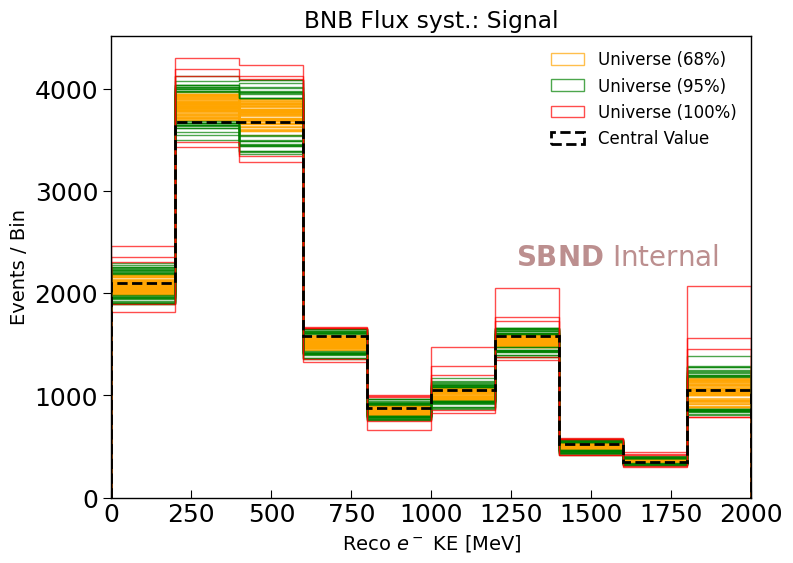

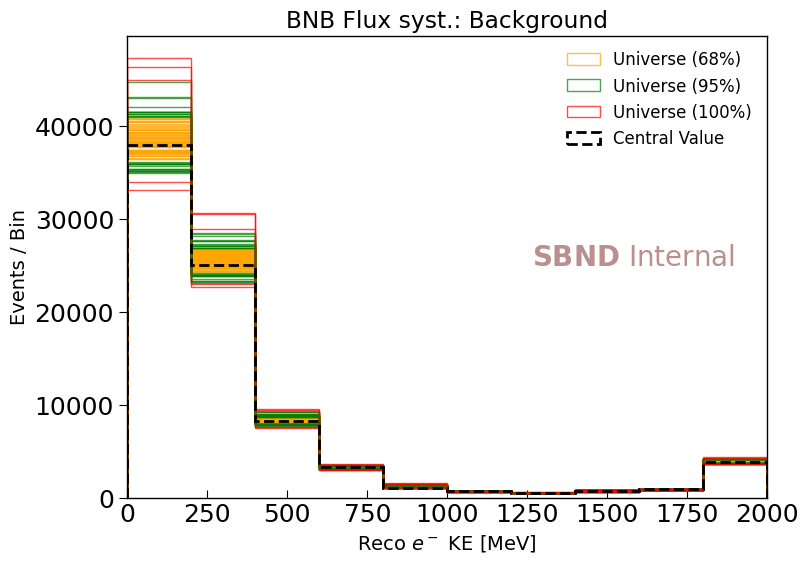

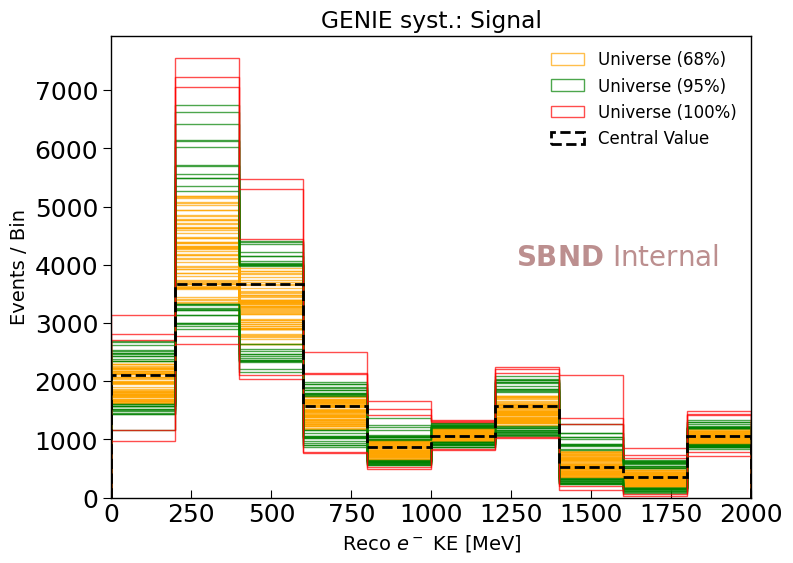

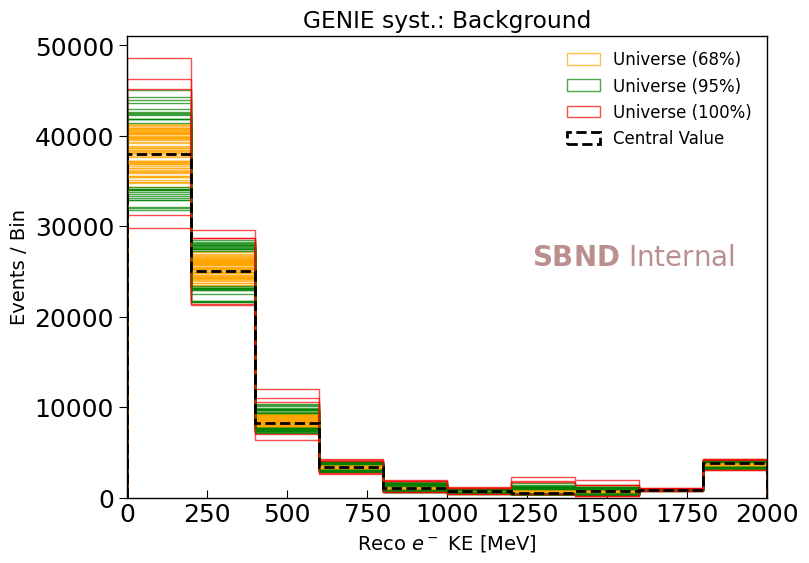

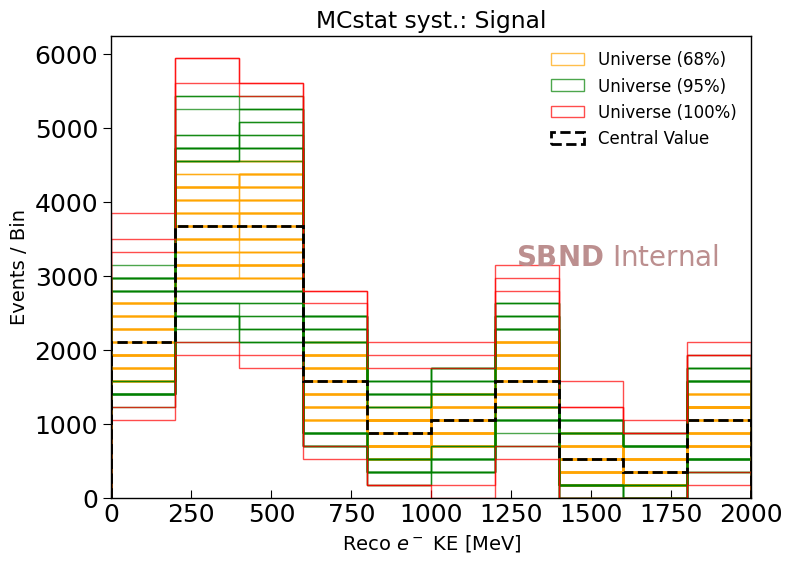

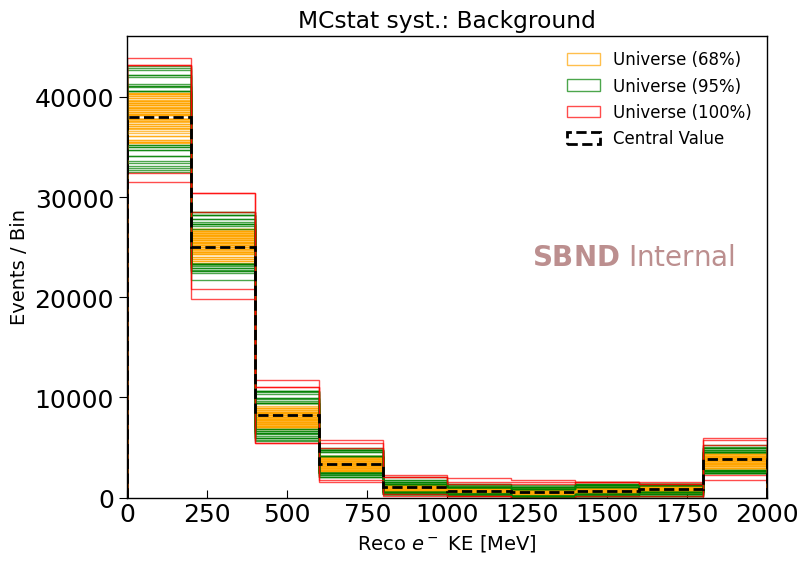

In [17]:
# =============================================================================
# CELL S5 — plot universe spread (uses cafpyana plot_univ_hists)
# =============================================================================
# plot_univ_hists expects (n_univ, n_bins) and a CV histogram
if bnb_cols:
    plot_univ_hists(flux_sig_univs,  ms_cv, "BNB Flux", varcfg, categ_name="Signal")
    plot_univ_hists(flux_bkg_univs,  bs_cv, "BNB Flux", varcfg, categ_name="Background")
 
if genie_cols:
    plot_univ_hists(genie_sig_univs, ms_cv, "GENIE",    varcfg, categ_name="Signal")
    plot_univ_hists(genie_bkg_univs, bs_cv, "GENIE",    varcfg, categ_name="Background")
 
plot_univ_hists(mcstat_sig_univs, ms_cv, "MCstat", varcfg, categ_name="Signal")
plot_univ_hists(mcstat_bkg_univs, bs_cv, "MCstat", varcfg, categ_name="Background")

/home/castalyf/cafpyana/analysis_village/unfolding/covariance.py:59: RuntimeWarning: invalid value encountered in sqrt
  corr[i, j] = cov[i, j] / (np.sqrt(cov[i, i]) * np.sqrt(cov[j, j]))


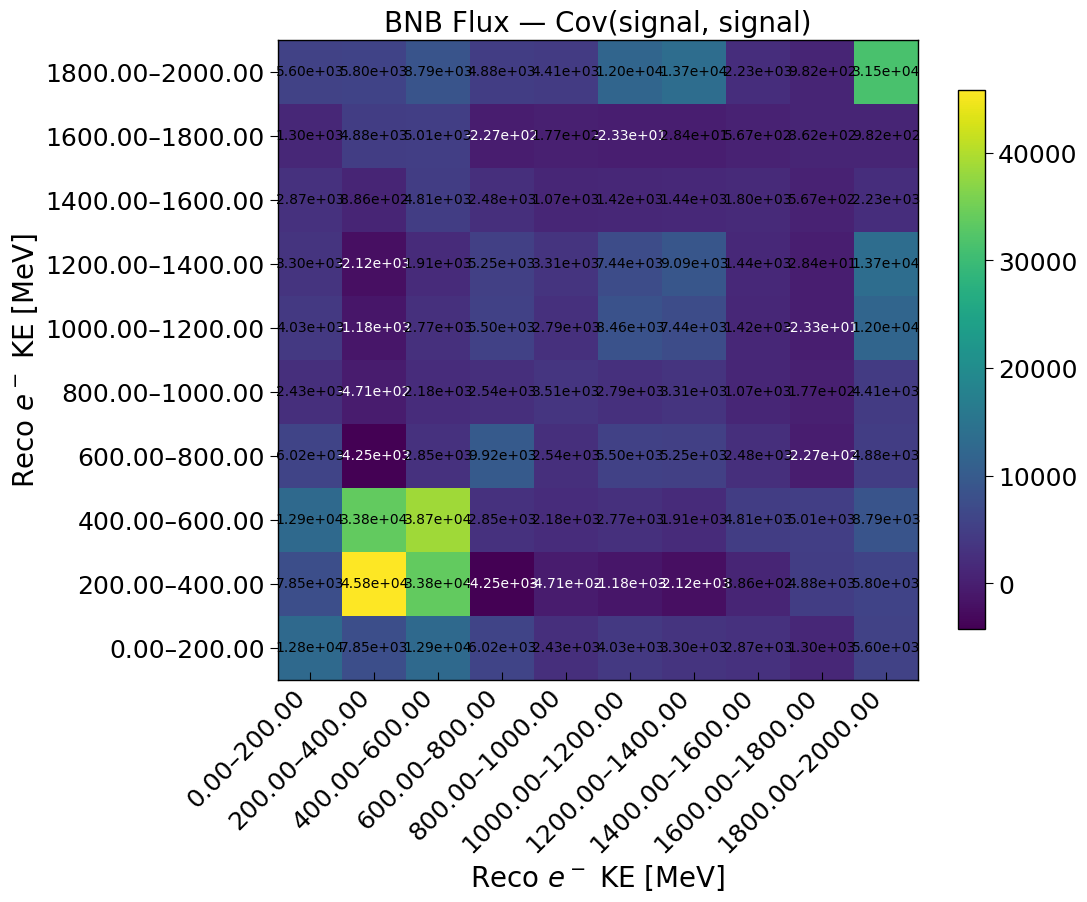

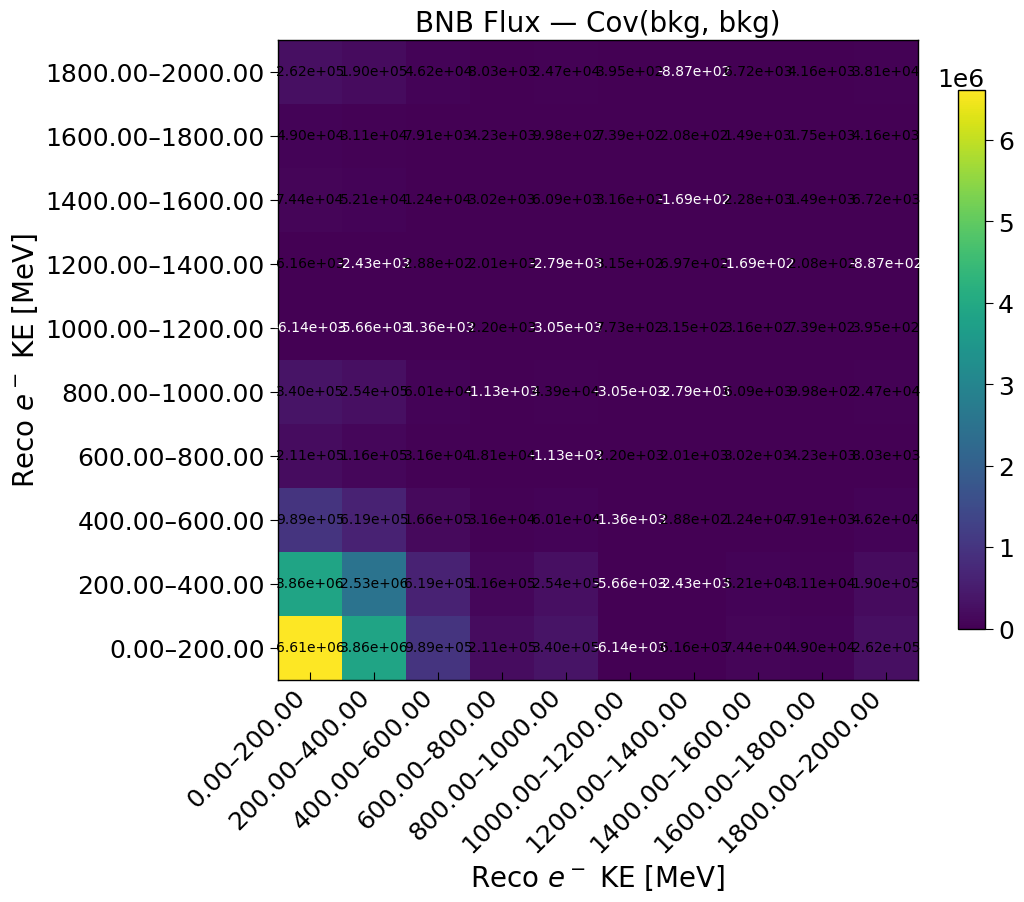

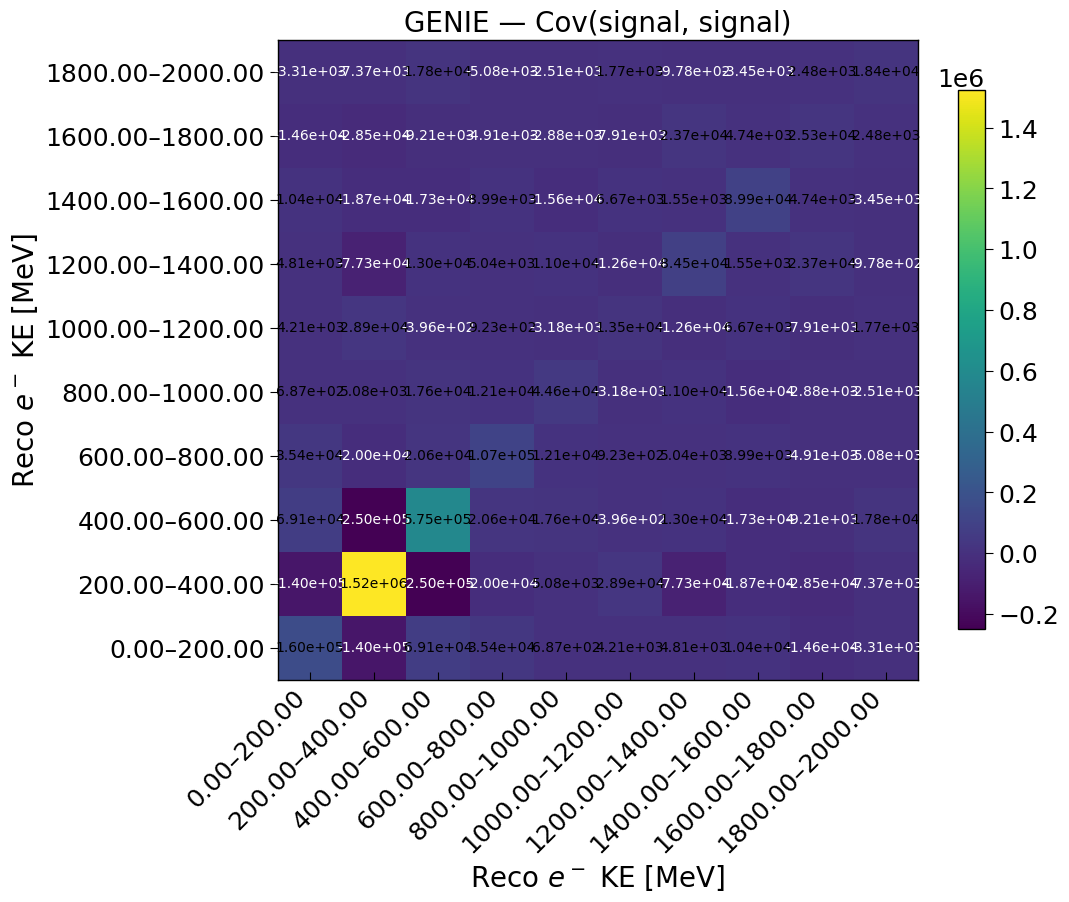

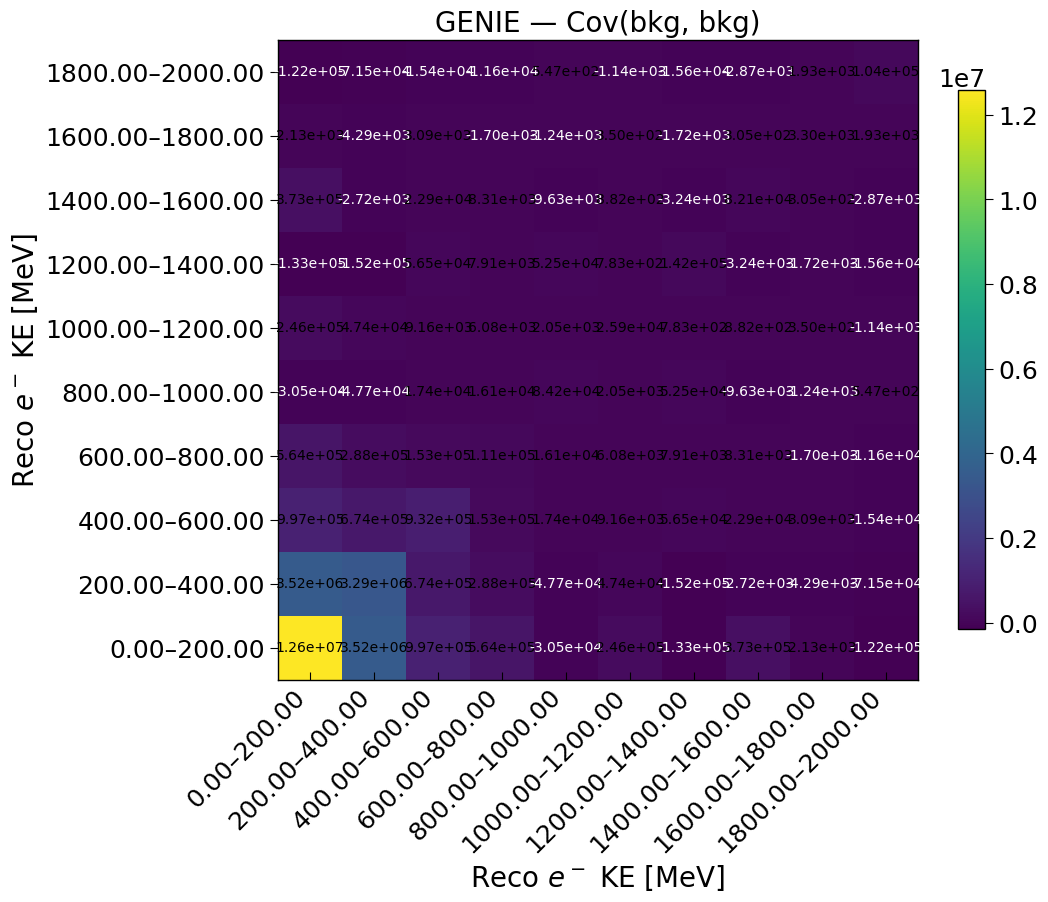

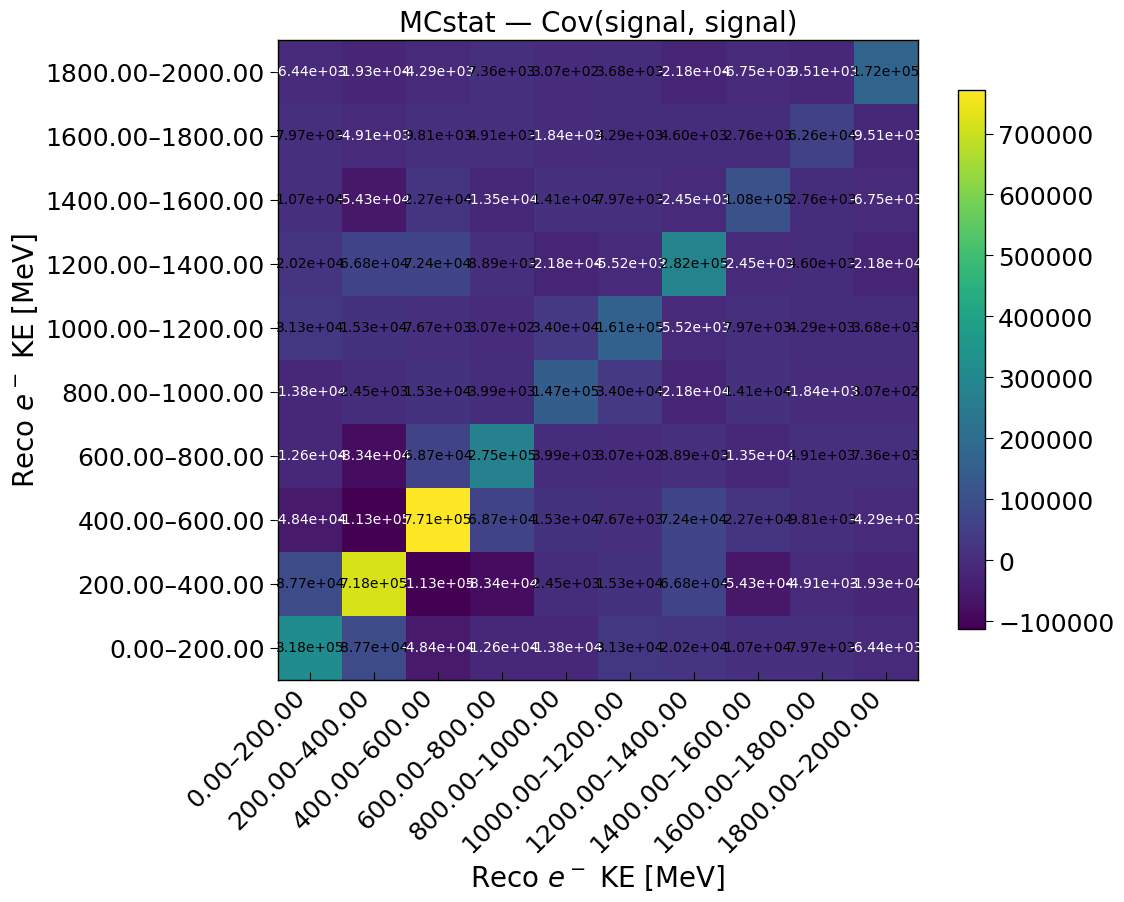

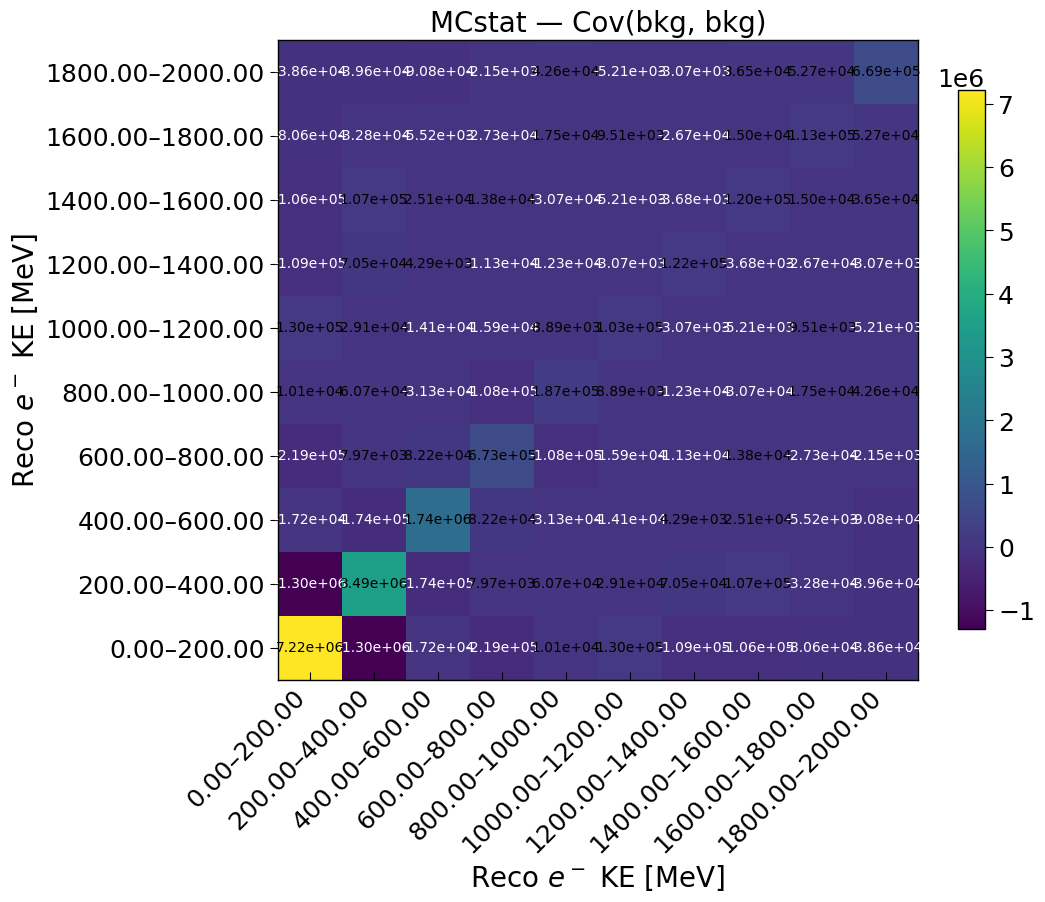

In [18]:
# =============================================================================
# CELL S6 — covariance matrices using cafpyana get_covariance_matrix_self
# =============================================================================
def _make_covs(sig_univs, bkg_univs, sig_cv, bkg_cv):
    return {
        "cov_ms_ms": get_covariance_matrix_self(sig_univs, sig_cv),
        "cov_bs_bs": get_covariance_matrix_self(bkg_univs, bkg_cv),
        "cov_ms_bs": get_covariance_matrix(sig_univs, sig_cv, bkg_univs, bkg_cv),
        "cov_bs_ms": get_covariance_matrix(bkg_univs, bkg_cv, sig_univs, sig_cv),
    }
 
covs_flux   = _make_covs(flux_sig_univs,   flux_bkg_univs,   ms_cv, bs_cv)
covs_genie  = _make_covs(genie_sig_univs,  genie_bkg_univs,  ms_cv, bs_cv)
covs_mcstat = _make_covs(mcstat_sig_univs, mcstat_bkg_univs, ms_cv, bs_cv)
 
# Plot heatmaps
for name, covs in [("BNB Flux", covs_flux), ("GENIE", covs_genie), ("MCstat", covs_mcstat)]:
    plot_heatmap(covs["cov_ms_ms"]["cov"], varcfg, title=f"{name} — Cov(signal, signal)")
    plot_heatmap(covs["cov_bs_bs"]["cov"], varcfg, title=f"{name} — Cov(bkg, bkg)")
 

In [19]:
# =============================================================================
# CELL S7 — save to .npz (same structure as cohpi, ready for xsec notebook)
# =============================================================================
import os
COV_DIR = "./nuecc_cov"
os.makedirs(COV_DIR, exist_ok=True)
 
def _save_npz(path, sig_cv, bkg_cv, true_signal, response, covs):
    np.savez(path,
        ms          = sig_cv,
        bs          = bkg_cv,
        true_signal = true_signal,
        response    = response,
        **covs,
    )
    print(f"Saved → {path}  ({os.path.getsize(path)/1024:.0f} KB)")
 
_save_npz(f"{COV_DIR}/flux_syst_cov_matrices.npz",
          ms_cv, bs_cv, true_signal_cv, response, covs_flux)
 
_save_npz(f"{COV_DIR}/genie_syst_cov_matrices.npz",
          ms_cv, bs_cv, true_signal_cv, response, covs_genie)
 
_save_npz(f"{COV_DIR}/mcstat_syst_cov_matrices.npz",
          ms_cv, bs_cv, true_signal_cv, response, covs_mcstat)
 
print("\nAll covariance files saved. Ready for xsec/unfolding notebook.")
print(f"Files: {os.listdir(COV_DIR)}")

Saved → ./nuecc_cov/flux_syst_cov_matrices.npz  (14 KB)
Saved → ./nuecc_cov/genie_syst_cov_matrices.npz  (14 KB)
Saved → ./nuecc_cov/mcstat_syst_cov_matrices.npz  (14 KB)

All covariance files saved. Ready for xsec/unfolding notebook.
Files: ['mcstat_syst_cov_matrices.npz', 'flux_syst_cov_matrices.npz', 'genie_syst_cov_matrices.npz']


In [20]:
# # in syst notebook — run once per variable
# for var_name, bins in [("electron_ke",    BINS_KE),
#                         ("electron_p",     BINS_P),
#                         ("electron_costheta", BINS_COS)]:
#     # recompute ms_cv, bs_cv, response, covs with these bins
#     # then save:
#     _save_npz(f"{COV_DIR}/{var_name}_flux_syst_cov_matrices.npz",  ...)
#     _save_npz(f"{COV_DIR}/{var_name}_genie_syst_cov_matrices.npz", ...)
#     _save_npz(f"{COV_DIR}/{var_name}_mcstat_syst_cov_matrices.npz",...)

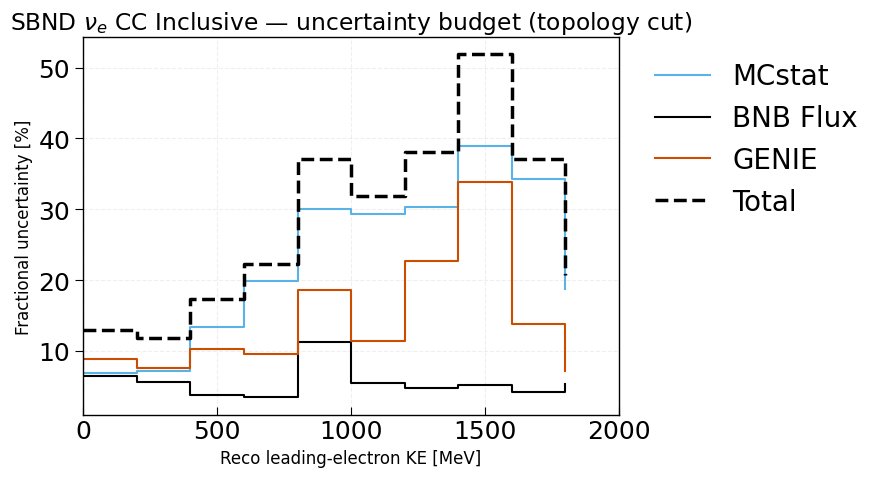

In [21]:
# =============================================================================
# CELL S8 — fractional uncertainty summary plot
# =============================================================================
total_pred = ms_cv + bs_cv
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"MCstat": "C2", "BNB Flux": "C0", "GENIE": "C1"}
 
total_cov = np.zeros((len(RECO_BINS)-1, len(RECO_BINS)-1))
for name, covs in [("MCstat", covs_mcstat), ("BNB Flux", covs_flux), ("GENIE", covs_genie)]:
    c = covs["cov_ms_ms"]["cov"] + covs["cov_bs_bs"]["cov"]
    total_cov += c
    frac = np.sqrt(np.diag(c)) / np.where(total_pred > 0, total_pred, np.nan)
    ax.step(RECO_BINS[:-1], frac * 100, where="post",
            label=name, color=colors[name], lw=1.5)
 
total_frac = np.sqrt(np.diag(total_cov)) / np.where(total_pred > 0, total_pred, np.nan)
ax.step(RECO_BINS[:-1], total_frac * 100, where="post",
        label="Total", color="black", lw=2.5, linestyle="--")
 
ax.set_xlabel("Reco leading-electron KE [MeV]", fontsize=12)
ax.set_ylabel(r"Fractional uncertainty [%]", fontsize=12)
ax.set_title(fr"{TITLE} — uncertainty budget (topology cut)")
ax.set_xlim(RECO_BINS[0], RECO_BINS[-1])
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()
nh.save_plot("uncertainty_budget_topo", fig=fig, folder_name=PLOT_DIR)

In [22]:
%reset -f